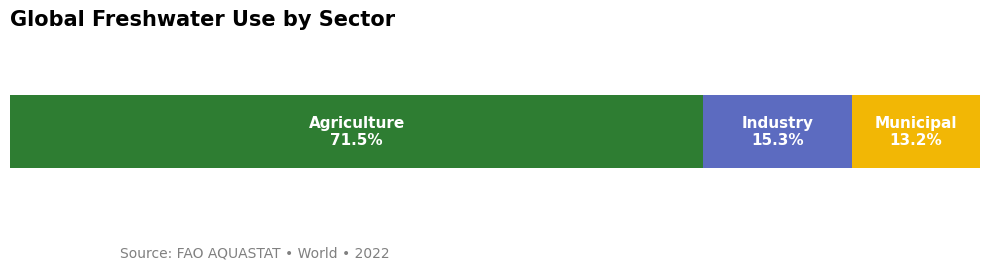

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("AQUASTAT Dissemination System.csv")

variables = [
    "Agricultural water withdrawal",
    "Industrial water withdrawal",
    "Municipal water withdrawal",
    "Total water withdrawal"
]

filtered = df[
    (df["Area"] == "World") &
    (df["Year"] == 2022) &
    (df["Variable"].isin(variables))
].copy()

data = filtered[["Variable", "Value"]].set_index("Variable")["Value"]

agriculture = data["Agricultural water withdrawal"]
industry = data["Industrial water withdrawal"]
municipal = data["Municipal water withdrawal"]
total = data["Total water withdrawal"]

shares = {
    "Agriculture": agriculture / total * 100,
    "Industry": industry / total * 100,
    "Municipal": municipal / total * 100
}

colors = {
    "Agriculture": "#2E7D32",
    "Industry": "#5C6BC0",
    "Municipal": "#F2B705"
}

fig, ax = plt.subplots(figsize=(10, 2.5))

left = 0
for label, value in shares.items():
    ax.barh(
        y=0,
        width=value,
        left=left,
        color=colors[label],
        height=0.6
    )
    
    ax.text(
        left + value / 2,
        0,
        f"{label}\n{value:.1f}%",
        ha="center",
        va="center",
        fontsize=11,
        color="white",
        fontweight="bold"
    )
    
    left += value

ax.set_xlim(0, 100)
ax.set_ylim(-0.8, 0.8)
ax.axis("off")

plt.title("Global Freshwater Use by Sector", fontsize=15, fontweight="bold", loc="left")
plt.figtext(
    0.125, -0.05,
    "Source: FAO AQUASTAT • World • 2022",
    ha="left",
    fontsize=10,
    color="gray"
)

plt.tight_layout()
plt.savefig("water_use_sector.svg", dpi=300, bbox_inches="tight")
plt.show()

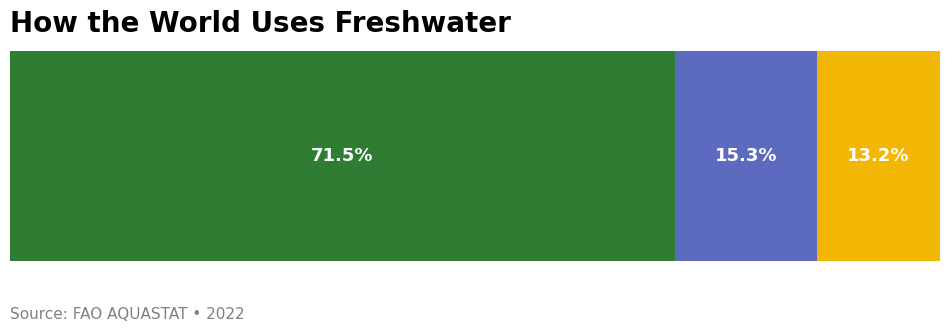

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("AQUASTAT Dissemination System.csv")

variables = [
    "Agricultural water withdrawal",
    "Industrial water withdrawal",
    "Municipal water withdrawal",
    "Total water withdrawal"
]

filtered = df[
    (df["Area"] == "World") &
    (df["Year"] == 2022) &
    (df["Variable"].isin(variables))
]

data = filtered.set_index("Variable")["Value"]

agriculture = data["Agricultural water withdrawal"]
industry = data["Industrial water withdrawal"]
municipal = data["Municipal water withdrawal"]
total = data["Total water withdrawal"]

shares = [
    agriculture/total*100,
    industry/total*100,
    municipal/total*100
]

labels = ["Agriculture","Industry","Municipal"]
colors = ["#2E7D32","#5C6BC0","#F2B705"]

fig, ax = plt.subplots(figsize=(12,3))

left = 0

for value,label,color in zip(shares,labels,colors):

    ax.barh(
        y=0,
        width=value,
        left=left,
        color=color,
        height=0.55
    )

    ax.text(
        left + value/2,
        0,
        f"{value:.1f}%",
        ha="center",
        va="center",
        fontsize=13,
        color="white",
        fontweight="bold"
    )

    left += value

ax.set_xlim(0,100)
ax.axis("off")

plt.title(
    "How the World Uses Freshwater",
    fontsize=20,
    fontweight="bold",
    loc="left"
)

plt.figtext(
    0.125,
    -0.05,
    "Source: FAO AQUASTAT • 2022",
    fontsize=11,
    color="gray"
)

fig.savefig("global_water_use_sector.svg", bbox_inches="tight")

plt.show()